## c0: Atualizações e download d dependenias

In [ ]:
# ==============================================================
# Correção da Instalação — executa cada pacote separadamente
# ==============================================================
!pip install --upgrade pip
!pip install scikit-learn==1.4.2
!pip install scikeras==0.12.0
!pip install tensorflow==2.15.0
!pip install pandas==2.2.2
!pip install numpy==1.26.4
!pip install matplotlib==3.9.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 54.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 134.3 MB/s  0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
cuml-cu12 25.6.0 requires scikit-learn>=1.5, but you have scikit-learn 1.4.2 which is incompatible.
ERROR: Ignored the following versions that require a different python version: 0.10.0 Requires-Python >=3.7.0,<3.11.0; 0.11.0 Requires-Python >=3.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 87.9 MB/s  0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
ERROR: Operation cancelled by user
^C


## C1: Configuração do Ambiente e Bibliotecas.

In [ ]:
# Instalação necessária para integrar Keras com Scikit-learn
!pip install scikeras

# 1. Importação de Bibliotecas Essenciais
import pandas as pd
import numpy as np
import os
import locale
from datetime import datetime, date

# Bibliotecas de Pré-processamento e Validação
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scikeras.wrappers import KerasRegressor

# Bibliotecas de Modelagem de Rede Neural (MLP)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, RMSprop, Adagrad
from tensorflow.keras.callbacks import EarlyStopping

# Biblioteca para plotagem de gráficos
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 2. Configuração de Locale para datas em português (ex: jan, fev) [3]
# Tenta configurar o locale para português do Brasil
import locale

try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
except:
    # Fallback seguro e neutro
    locale.setlocale(locale.LC_ALL, '')
    print("Aviso: Locale 'pt_BR.UTF-8' não disponível. Usando configuração padrão do sistema.")


print("Configurações concluídas. O ambiente de trabalho está pronto.")

Aviso: Locale 'pt_BR.UTF-8' não disponível. Usando configuração padrão do sistema.
Configurações concluídas. O ambiente de trabalho está pronto.


## C2: Ingestão de Dados e Pré-processamento

Esta célula carrega o arquivo CSV, converte a coluna de datas corretamente (lidando com os meses abreviados em português) e prepara a série temporal de vazão.

--- Primeiros Registros (Data e Vazão) ---
            vazao
data             
1931-01-01  16060
1931-01-02  15935
1931-01-03  15559
1931-01-04  15309
1931-01-05  15109

--- Informações da Série Temporal ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 31412 entries, 1931-01-01 to 2016-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   vazao   31412 non-null  int64
dtypes: int64(1)
memory usage: 490.8 KB
None


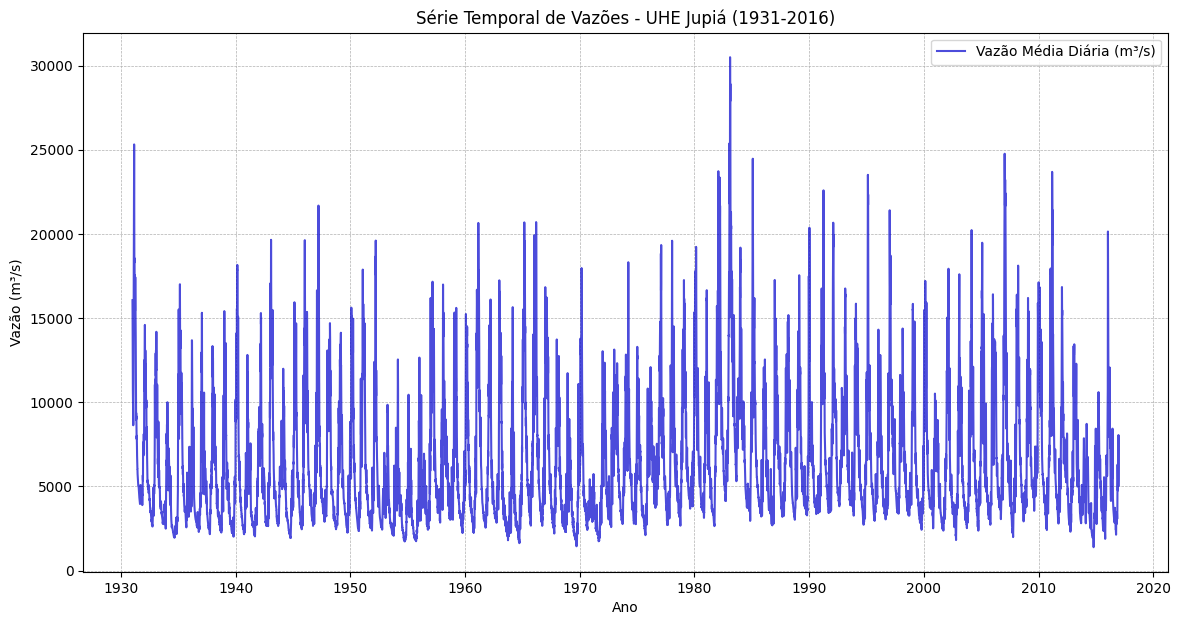

In [ ]:
# Link direto para download do CSV no Google Drive
DRIVE_FILE_ID = '1JMALdp_zahSRRPaIkNGHYohlTmntmXLj'
# Usando o formato 'uc?export=download' para forçar o download direto
DOWNLOAD_URL = f'https://drive.google.com/uc?export=download&id={DRIVE_FILE_ID}'

# 1. Leitura do Arquivo CSV [1]
# Utiliza o parâmetro `encoding='latin1'` ou 'iso-8859-1' para compatibilidade com CSVs
# gerados em ambientes Windows/português, se necessário.
try:
    df = pd.read_csv(DOWNLOAD_URL, sep=',', encoding='latin1')
except Exception as e:
    print(f"Erro ao carregar o arquivo CSV: {e}")
    # Tentar com o arquivo local de pesquisa se o download falhar (uso interno)
    df = pd.read_csv('Vazões_Diárias_JUPIA - Tabela.csv', sep=',')


# 2. Conversão da Coluna 'data' para Datetime
# O formato '%d/%b/%Y' lida com o dia/mês abreviado/ano. O locale em C1 garante o reconhecimento do mês abreviado em pt-BR.
# Tenta converter datas com meses em português
try:
    df['data'] = pd.to_datetime(df['data'], format='%d/%b/%Y', errors='raise')
except ValueError:
    # Se falhar (mês em português), converte de forma flexível
    meses_pt = {
        'jan': 'jan', 'fev': 'feb', 'mar': 'mar', 'abr': 'apr', 'mai': 'may', 'jun': 'jun',
        'jul': 'jul', 'ago': 'aug', 'set': 'sep', 'out': 'oct', 'nov': 'nov', 'dez': 'dec'
    }
    df['data'] = (
        df['data']
        .str.lower()
        .replace(meses_pt, regex=True)
        .pipe(pd.to_datetime, format='%d/%b/%Y')
    )


# 3. Definição do Índice Cronológico
df.set_index('data', inplace=True)

# 4. Inspeção e Visualização Inicial da Série
print("--- Primeiros Registros (Data e Vazão) ---")
print(df.head())
print("\n--- Informações da Série Temporal ---")
print(df.info())

# Plotagem da Série Temporal Bruta (Visualização Gráfica)
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['vazao'], label='Vazão Média Diária (m³/s)', color='mediumblue', alpha=0.7)
plt.title('Série Temporal de Vazões - UHE Jupiá (1931-2016)')
plt.xlabel('Ano')
plt.ylabel('Vazão (m³/s)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## C3: Particionamento Cronológico e Escalonamento
É crucial dividir os dados cronologicamente: Treino/Validação até o final de 2010, e Teste Cego para 2011-2016. A normalização deve ser ajustada apenas nos dados de treino para evitar data leakage.

In [ ]:
# 1. Definição das Datas de Corte
CUTOFF_DATE_TRAIN = '2010-12-31'
CUTOFF_DATE_TEST = '2011-01-01'

# 2. Divisão da Série Temporal
# Separando dados de treino (até 2010) e teste (a partir de 2011)
train_data = df.loc[:CUTOFF_DATE_TRAIN, 'vazao'].values.astype(float).reshape(-1, 1)
test_data  = df.loc[CUTOFF_DATE_TEST:, 'vazao'].values.astype(float).reshape(-1, 1)

# 3. Escalonamento (Normalização)
scaler = MinMaxScaler(feature_range=(0, 1))

# Ajusta o scaler apenas nos dados de treino
scaler.fit(train_data)

train_scaled = scaler.transform(train_data)
test_scaled = scaler.transform(test_data)

print(f"Dados de Treinamento/Validação (até 2010): {len(train_data)} registros.")
print(f"Dados de Teste Cego (2011-2016): {len(test_data)} registros.")
print("Escalonamento concluído. O scaler foi ajustado apenas nos dados de treino.")

Dados de Treinamento/Validação (até 2010): 29220 registros.
Dados de Teste Cego (2011-2016): 2192 registros.
Escalonamento concluído. O scaler foi ajustado apenas nos dados de treino.


# C4: Engenharia de Features:
`create_sequences` -> Esta função transforma a série temporal em um formato supervisionado, onde $X$ é a janela de observações passadas (n_lags) e $Y$ é o vetor de 7 valores futuros (n_future = 7).

In [ ]:
# Horizonte de Previsão Fixo em 7 dias (saída com 7 neurônios)
N_FUTURE = 7

def create_sequences(data, n_lags, n_future=N_FUTURE):
    """
    Cria a estrutura de dados X (entradas, lags) e Y (saídas, 7 passos futuros).
    """
    X, Y = list(), list()
    for i in range(len(data)):
        end_ix = i + n_lags
        out_end_ix = end_ix + n_future
        if out_end_ix > len(data):
            break
        seq_x = data[i:end_ix, 0]
        seq_y = data[end_ix:out_end_ix, 0]
        X.append(seq_x)
        Y.append(seq_y)
    return np.array(X), np.array(Y)

# Lags a serem testados futuramente na C6 (Grid Search)
Lags_to_test = [15, 30, 45]

# Exemplo de geração usando o primeiro lag (L = 15)
example_lag = Lags_to_test[0]
X_train_ex, Y_train_ex = create_sequences(train_scaled, n_lags=example_lag)

print(f"Exemplo de X_train shape (L={example_lag}): {X_train_ex.shape}")
print(f"Exemplo de Y_train shape (N_FUTURE=7): {Y_train_ex.shape}")


Exemplo de X_train shape (L=15): (29199, 15)
Exemplo de Y_train shape (N_FUTURE=7): (29199, 7)


## C5: Definição do Modelo MLP
para o KerasRegressor
Esta célula define o modelo MLP de forma genérica, permitindo que o GridSearchCV explore as combinações de hiperparâmetros (lags, camadas, neurônios).

In [ ]:
# 1. Definição da Arquitetura MLP (Wrapper Function) [5]
def create_mlp_model(n_layers=1, n_neurons=20, n_lags=15, optimizer='adam', learning_rate=0.001):
    """
    Cria, compila e retorna um modelo Keras MLP parametrizado.

    Args:
        n_layers (int): Número de camadas ocultas (1 ou 2).
        n_neurons (int): Número de neurônios por camada oculta.
        n_lags (int): Dimensão da entrada (número de lags).
        optimizer (str): Algoritmo de otimização (Adam, RMSprop, Adagrad).
    """
    model = Sequential()

    # 1ª Camada Oculta (recebe a dimensão de entrada n_lags)
    model.add(Dense(n_neurons, activation='relu', input_shape=(n_lags,)))

    # 2ª Camada Oculta (condicional, se n_layers for 2)
    if n_layers == 2:
        model.add(Dense(n_neurons, activation='relu'))

    # Camada de Saída (FIXA em N_FUTURE=7 neurônios, com ativação linear para regressão)
    model.add(Dense(N_FUTURE, activation='linear'))

    # Configuração do Otimizador (usando Adam como padrão, mas pode ser RMSprop/Adagrad)
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer == 'adagrad':
        opt = Adagrad(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate) # Fallback

    # Compilação do Modelo (Função Custo: Erro Médio Quadrático - MSE)
    model.compile(optimizer=opt, loss='mse')

    return model

print("Função create_mlp_model definida.")

Função create_mlp_model definida.


## C6: Otimização de Hiperparâmetros (Grid Search)
Esta é a célula mais importante, onde a busca exaustiva sobre as 18 arquiteturas (3 lags x 2 camadas x 3 neurônios) é realizada. Utiliza-se TimeSeriesSplit para a validação cruzada cronológica e EarlyStopping para regular o treinamento.

### defasado:

In [ ]:
# 1. Definição do Espaço de Busca
param_grid = {
    'model__n_layers': [1, 2],                # 1 ou 2 Camadas Ocultas
    'model__n_neurons': [20, 40, 60],         # 20, 40 ou 60 Neurônios/Camada
    'optimizer': ['adam', 'rmsprop'],         # Otimizadores sugeridos
    'model__n_lags': []                       # Será definido externamente
}

# Parâmetros fixos para treinamento
keras_fit_params = {
    'epochs': 200,                            # Máximo de épocas
    'batch_size': 32,
    'callbacks': [
        EarlyStopping(monitor='loss', patience=10, verbose=0, mode='min')
    ],
    'verbose': 0                              # Suprime saída de cada época
}

# 2. Configuração da Validação Cruzada Temporal
tscv = TimeSeriesSplit(n_splits=5)

# Lista para armazenar os melhores modelos de cada lag
best_models = []

# Conjunto de lags a serem testados
lags_to_test = [15, 30, 45]

print("Iniciando Grid Search...")

# 3. Loop de Teste para cada Lag (L)
for n_lags in lags_to_test:
    print(f"\n--- Testando Lag (L) = {n_lags} dias ---")

    # A. Criação dos dados de treino para o lag atual
    X_train, Y_train = create_sequences(train_scaled, n_lags=n_lags)

    # B. Modelo Base — configurado para integração com GridSearchCV
    mlp_base = KerasRegressor(
        model=create_mlp_model,
        n_lags=n_lags,
        loss='mse',
        verbose=0
    )

    # C. Grade temporária (sem n_lags, pois é iterado externamente)
    temp_param_grid = {k: v for k, v in param_grid.items() if 'n_lags' not in k}
    temp_param_grid['model__n_lags'] = [n_lags]  # metadado

    # D. Configuração do GridSearchCV
    grid = GridSearchCV(
        estimator=mlp_base,
        param_grid=temp_param_grid,
        cv=tscv,
        scoring='neg_mean_squared_error',
        verbose=1,
        n_jobs=-1,
        error_score='raise'
    )

    # E. Execução do Grid Search
    try:
        grid_result = grid.fit(X_train, Y_train, **keras_fit_params)

        # Armazena o melhor modelo para este lag
        best_models.append({
            'n_lags': n_lags,
            'best_score_mse': -grid_result.best_score_,  # MSE positivo
            'best_params': grid_result.best_params_,
            'best_estimator': grid_result.best_estimator_
        })

        print(f"Melhor MSE (Validação) para L={n_lags}: {-grid_result.best_score_:.2f}")
        print(f"Melhores parâmetros para L={n_lags}: {grid_result.best_params_}")

    except Exception as e:
        print(f"Erro na execução do GridSearchCV para L={n_lags}: {e}")

# 4. Consolidação dos Resultados Finais
print("\n--- Consolidação dos Resultados do Grid Search ---")

if best_models:
    # Encontra o melhor modelo global (menor MSE)
    final_best_model_data = min(best_models, key=lambda x: x['best_score_mse'])

    L_STAR = final_best_model_data['n_lags']
    H_STAR = final_best_model_data['best_params']['model__n_layers']
    N_STAR = final_best_model_data['best_params']['model__n_neurons']
    OPTIMIZER_STAR = final_best_model_data['best_params']['optimizer']
    MSE_STAR = final_best_model_data['best_score_mse']

    print(f"\nMODELO ÓTIMO SELECIONADO (M*):")
    print(f"  - Lags (L*): {L_STAR} dias")
    print(f"  - Camadas Ocultas (H*): {H_STAR}")
    print(f"  - Neurônios/Camada (N*): {N_STAR}")
    print(f"  - Otimizador: {OPTIMIZER_STAR}")
    print(f"  - MSE Médio na Validação: {MSE_STAR:.2f}")

else:
    print("Nenhum modelo foi treinado com sucesso. Verifique os passos anteriores.")


Iniciando Grid Search...

--- Testando Lag (L) = 15 dias ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits


## Atual, por chamada

In [ ]:
import time
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from scikeras.wrappers import KerasRegressor
from tensorflow.keras.callbacks import EarlyStopping

# ======================================================================
# FUNÇÃO PRINCIPAL DE GRID SEARCH PARA UM DETERMINADO LAG
# ======================================================================
def executar_grid_search_para_lag(train_scaled, n_lags, param_grid, keras_fit_params, n_splits=5):
    """
    Executa o GridSearchCV para um lag específico, com monitoramento e tratamento de erros.

    Args:
        train_scaled (np.array): Dados de treinamento escalonados.
        n_lags (int): Quantidade de defasagens (lags) a testar.
        param_grid (dict): Espaço de busca de hiperparâmetros.
        keras_fit_params (dict): Parâmetros fixos para treinamento Keras.
        n_splits (int): Número de divisões temporais (default=5).

    Returns:
        dict: Dados do melhor modelo encontrado (ou None, em caso de falha).
    """
    print("=" * 90)
    print(f"🕓 Iniciando Grid Search para Lag (L) = {n_lags} dias...")
    print("=" * 90)
    start_time = time.time()

    try:
        # A. Criação dos dados supervisionados
        X_train, Y_train = create_sequences(train_scaled, n_lags=n_lags)
        print(f"✅ Dados criados: X_train={X_train.shape}, Y_train={Y_train.shape}")

        # B. Criação do modelo base
        mlp_base = KerasRegressor(
            model=create_mlp_model,
            n_lags=n_lags,
            loss='mse',
            verbose=0
        )

        # C. Definição da grade temporária (sem n_lags interno)
        temp_param_grid = {k: v for k, v in param_grid.items() if 'n_lags' not in k}
        temp_param_grid['model__n_lags'] = [n_lags]

        # D. Configuração da Validação Cruzada Temporal
        tscv = TimeSeriesSplit(n_splits=n_splits)

        # E. Execução do GridSearchCV
        grid = GridSearchCV(
            estimator=mlp_base,
            param_grid=temp_param_grid,
            cv=tscv,
            scoring='neg_mean_squared_error',
            verbose=2,
            n_jobs=-1,
            error_score='raise'
        )

        print(f"▶️ Rodando GridSearchCV para L={n_lags} ...")
        grid_result = grid.fit(X_train, Y_train, **keras_fit_params)
        elapsed = (time.time() - start_time) / 60

        # F. Armazena o melhor resultado
        best_model_info = {
            'n_lags': n_lags,
            'best_score_mse': -grid_result.best_score_,
            'best_params': grid_result.best_params_,
            'best_estimator': grid_result.best_estimator_,
            'tempo_execucao_min': elapsed
        }

        print(f"✅ Concluído Lag={n_lags} | Melhor MSE={-grid_result.best_score_:.4f} | Tempo={elapsed:.1f} min")
        print(f"🔧 Melhores parâmetros: {grid_result.best_params_}")
        print("=" * 90)
        return best_model_info

    except Exception as e:
        print(f"❌ Erro durante o GridSearch para L={n_lags}: {e}")
        print("⏹️ Pulando este lag e seguindo adiante.")
        print("=" * 90)
        return None


# ======================================================================
# CONFIGURAÇÃO PADRÃO DE PARÂMETROS (reutilizável)
# ======================================================================
param_grid = {
    'model__n_layers': [1, 2],
    'model__n_neurons': [20, 40], ########          tirei os 60
    'optimizer': ['adam', 'rmsprop'],
    'model__n_lags': []  # metadado externo
}

keras_fit_params = {
    'epochs': 50,   ########          tirei os 200, coloquei 50
    'batch_size': 32,
    'callbacks': [
        EarlyStopping(monitor='loss', patience=10, verbose=0, mode='min')
    ],
    'verbose': 0
}

chamadas: 15, 30, 45

In [ ]:
best_15 = executar_grid_search_para_lag(train_scaled, 15, param_grid, keras_fit_params)

🕓 Iniciando Grid Search para Lag (L) = 15 dias...
✅ Dados criados: X_train=(29199, 15), Y_train=(29199, 7)
▶️ Rodando GridSearchCV para L=15 ...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [ ]:
best_30 = executar_grid_search_para_lag(train_scaled, 30, param_grid, keras_fit_params)

In [ ]:
best_45 = executar_grid_search_para_lag(train_scaled, 45, param_grid, keras_fit_params)

# Testar:

## C7: Re-treinamento do Modelo Otimizado
($M^*$)O modelo com os hiperparâmetros ótimos ($L^*, H^*, N^*, Otimizador^*$) é re-treinado utilizando todos os dados de treinamento/validação (1931-2010), para maximizar sua capacidade antes da avaliação final.

In [ ]:
# Utilizando os hiperparâmetros ótimos encontrados na Célula C6
try:
    # 1. Geração do conjunto de dados completo de Treino/Validação (1931-2010)
    X_full_train, Y_full_train = create_sequences(train_scaled, n_lags=L_STAR)

    # 2. Re-criação do modelo com os hiperparâmetros ótimos (M*)
    final_model = KerasRegressor(
        model=create_mlp_model,
        n_lags=L_STAR,
        n_layers=H_STAR,
        n_neurons=N_STAR,
        optimizer=OPTIMIZER_STAR,
        loss='mse',
        verbose=1,
        # Mantendo os parâmetros de fit originais (epochs e early stopping)
        epochs=keras_fit_params['epochs'],
        batch_size=keras_fit_params['batch_size'],
        callbacks=keras_fit_params['callbacks']
    )

    # 3. Re-treinamento no conjunto completo (até 2010)
    print("\nIniciando re-treinamento do Modelo Ótimo (M*) no período 1931-2010...")
    final_model.fit(X_full_train, Y_full_train)
    print("Re-treinamento concluído. O modelo M* está pronto para a avaliação final (teste cego).")

except NameError:
    print("ERRO: As variáveis ótimas (L_STAR, H_STAR, etc.) não foram definidas. Execute a Célula C6 primeiro.")
except Exception as e:
    print(f"Ocorreu um erro durante o re-treinamento do modelo: {e}")